# Taller de POO: Gestion y Analisis de Datos de Ventas

Resolucion del taller organizada paso a paso por fases (Abstraccion, Herencia, Mixins y Encapsulamiento).

En este proyecto procesamos el archivo `dataset.csv`, validamos la informacion, limpiamos los datos faltantes y generamos los reportes requeridos. Ademas agregamos una funcion propia para **exportar el dataset limpio a un nuevo archivo CSV** (`ventas_limpias.csv`) para guardar los resultados.

## Fase 1: Arquitectura Base y Mixins

En esta primera fase definimos la estructura basica del proyecto utilizando **Abstraccion** y **Mixins**:

- **Clase Abstracta (`ComponenteDatos`):** Representa el modelo base o contrato para los componentes del pipeline. Obliga a que cualquier componente tenga implementado el metodo `ejecutar()`.
- **Mixins de Apoyo:**
  - `RegistradorMixin`: Aporta la habilidad de loguear mensajes en consola sin depender de una jerarquia fija.
  - `ValidadorMixin`: Aporta metodos reutilizables para comprobar que el archivo exista en disco y que no falten columnas requeridas en el DataFrame.

*Nota personal sobre Mixins:* Los mixins me sirvieron para separar habilidades ("sabe hacer") de la jerarquia principal ("es un"), lo que permite reusarlos en cualquier clase sin enredar el codigo.

In [5]:
import os
from abc import ABC, abstractmethod
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Fase 1: Arquitectura base y Mixins
# ==========================================

class ComponenteDatos(ABC):
    """Clase abstracta base. Todas las partes del pipeline tienen q implementar ejecutar()"""
    @abstractmethod
    def ejecutar(self):
        pass


class RegistradorMixin:
    """Mixin para loguear mensajes y no andar escribiendo print en todos lados"""
    def log(self, mensaje):
        print(f"[LOG] {mensaje}")


class ValidadorMixin:
    """Mixin con funciones de validacion q se pueden reusar en cualquier clase"""
    def validar_archivo(self, ruta):
        # si la ruta no existe devuelvo error para no seguir ejecutando a ciegas
        if not os.path.exists(ruta):
            raise FileNotFoundError(f"El archivo '{ruta}' no fue encontrado.")
        return True

    def validar_columnas(self, df, columnas_requeridas):
        # reviso si falta alguna columna obligatoria en el dataframe
        faltantes = [c for c in columnas_requeridas if c not in df.columns]
        if faltantes:
            raise ValueError(f"Faltan las siguientes columnas obligatorias: {faltantes}")
        return True


## Fase 2: Ingesta, Limpieza y Encapsulamiento

En esta fase creamos las clases encargadas de procesar los datos heredando de la clase base y de los mixins:

- **`CargadorDatos` (Herencia + Mixins):** Hereda de `ComponenteDatos` (porque **es un** componente) y usa los mixins `RegistradorMixin` y `ValidadorMixin`. Aplica **Encapsulamiento** definiendo `__ruta_archivo` como atributo privado (name mangling) para evitar que se modifique directamente desde fuera.
- **`LimpiadorDatos`:** Se encarga de imputar valores nulos (promedio para numericas, 'desconocido' para texto), convertir fechas al tipo correcto y verificar la integridad de las ventas.
- **`ExportadorMixin`:** Mixin adicional para guardar el DataFrame final en un archivo CSV (`ventas_limpias.csv`).

In [6]:
# ==========================================
# Fase 2: Carga, limpieza de nulos y exportacion
# ==========================================

class CargadorDatos(ComponenteDatos, RegistradorMixin, ValidadorMixin):
    def __init__(self, ruta_archivo):
        # atributo privado con name mangling para encapsular bien la ruta
        self.__ruta_archivo = ruta_archivo

    def ejecutar(self):
        self.log(f"Comprobando si existe el archivo: {self.__ruta_archivo}")
        self.validar_archivo(self.__ruta_archivo)

        self.log("Cargando el archivo CSV...")
        df = pd.read_csv(self.__ruta_archivo)
        self.log(f"Lectura exitosa. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
        return df


class LimpiadorDatos(ComponenteDatos, RegistradorMixin):
    def __init__(self, df):
        # saco una copia para no alterar el dataframe original x si acaso
        self.df = df.copy()

    def ejecutar(self):
        self.log("Arrancando proceso de limpieza y curacion de datos...")

        # Para las columnas numericas imputo los nulos usando el promedio (media)
        for col in self.df.select_dtypes(include=['number']).columns:
            if self.df[col].isnull().any():
                self.df[col] = self.df[col].fillna(self.df[col].mean())
                self.log(f"Se imputaron nulos con la media en la columna numerica: '{col}'")

        # Para texto/categoricas los nulos los cambio por 'desconcido'
        for col in self.df.select_dtypes(include=['object']).columns:
            if self.df[col].isnull().any():
                self.df[col] = self.df[col].fillna('desconcido')
                self.log(f"Se imputaron nulos con 'desconcido' en la columna categorica: '{col}'")

        # Conbercion de la columna fecha a formato datetime
        if 'fecha' in self.df.columns:
            self.df['fecha'] = pd.to_datetime(self.df['fecha'], errors='coerce')
            self.log("Conbercion de fecha realizada sin problemas.")

        # --- Validacion de integridad: no deberian haber ventas en negativo ---
        if 'ventas' in self.df.columns:
            ventas_invalidas = (self.df['ventas'] < 0).sum()
            if ventas_invalidas > 0:
                self.log(f"Alerta: se encontraron {ventas_invalidas} registros con ventas negativas!")
            else:
                self.log("Chekeo de integridad OK: no hay valores negativos en ventas.")

        self.log("Limpieza de datos finalizada.")
        return self.df

    @property
    def resumen_estadistico(self):
        """Propiedad para consultar el resumen estadistico de los datos limpios"""
        return self.df.describe(include='all')


class ExportadorMixin:
    """Mixin extra que cree para guardar cualquier dataframe a CSV al final"""
    def exportar_csv(self, df, ruta_salida):
        df.to_csv(ruta_salida, index=False)
        print(f"[LOG] Archivo limpio exportado correctamente en: {ruta_salida}")


## Fase 3: Analisis de Datos y Polimorfismo

En la tercera fase implementamos la clase `AnalistaDatos` para visualizar y analizar los resultados:

- **Polimorfismo:** El metodo `generar_reporte()` actua como orquestador polimorfico, llamando a diferentes salidas (reporte textual en consola y graficos de visualización) bajo una misma interfaz.
- **Visualizaciones:** Incluye el histograma de distribucion de ventas y una grafica de barras personalizada con el **total de ventas agrupado por producto**.

In [7]:
# ==========================================
# Fase 3: Analisis y visualizacion de datos
# ==========================================

class AnalistaDatos(RegistradorMixin, ExportadorMixin):
    def __init__(self, df):
        self.df = df

    def reporte_consola(self):
        self.log("Imprimiendo reporte basico en la consola...")
        print("\n" + "=" * 45)
        print("           REPORTE DESCRIPTIVO              ")
        print("=" * 45)
        print(f"Primeras filas:\n{self.df.head()}")
        print("\nTipos de datos de las columnas:")
        print(self.df.dtypes)
        print("=" * 45 + "\n")

    def grafico_distribucion(self):
        self.log("Generando histograma de distribucion...")
        num_cols = self.df.select_dtypes(include=['number']).columns
        if len(num_cols) == 0:
            self.log("No se encontraron columnas numericas para hacer la grafica.")
            return
        plt.figure(figsize=(9, 5))
        sns.set_theme(style="whitegrid")
        sns.histplot(data=self.df, x=num_cols[0], kde=True, color='#1b7a4a', bins=10)
        plt.title(f'Distribucion de {num_cols[0].capitalize()}', fontsize=14, fontweight='bold')
        plt.xlabel(num_cols[0].capitalize())
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

    def grafico_ventas_por_producto(self):
        """Grafica propia para comparar las ventas acumuladas por producto"""
        if 'producto' not in self.df.columns or 'ventas' not in self.df.columns:
            self.log("Faltan columnas de producto/ventas para armar esta grafica.")
            return
        self.log("Generando grafico de barras por producto...")
        resumen = self.df.groupby('producto', as_index=False)['ventas'].sum()
        plt.figure(figsize=(9, 5))
        sns.barplot(data=resumen, x='producto', y='ventas', color='#3d6acb')
        plt.title('Ventas totales por producto', fontsize=14, fontweight='bold')
        plt.xticks(rotation=35, ha='right')
        plt.ylabel('Ventas ($)')
        plt.xlabel('Producto')
        plt.tight_layout()
        plt.show()

    def generar_reporte(self):
        """Metodo principal que llama a las 3 salidas del reporte"""
        self.reporte_consola()
        self.grafico_distribucion()
        self.grafico_ventas_por_producto()


## Fase 4: Ejecucion Completa del Pipeline

Aca integramos todo el pipeline ejecutando secuencialmente la carga de `dataset.csv`, la validacion, la limpieza, el resumen estadistico (`@property`), la generacion de reportes polimorficos y finalmente la exportacion a `ventas_limpias.csv`.

=== INICIANDO PIPELINE DE DATOS ===
[LOG] Comprobando si existe el archivo: dataset.csv
[LOG] Cargando el archivo CSV...
[LOG] Lectura exitosa. Filas: 7, Columnas: 3
[LOG] Arrancando proceso de limpieza y curacion de datos...
[LOG] Se imputaron nulos con la media en la columna numerica: 'ventas'
[LOG] Se imputaron nulos con 'desconcido' en la columna categorica: 'fecha'
[LOG] Se imputaron nulos con 'desconcido' en la columna categorica: 'producto'
[LOG] Conbercion de fecha realizada sin problemas.
[LOG] Chekeo de integridad OK: no hay valores negativos en ventas.
[LOG] Limpieza de datos finalizada.

--- Resumen estadistico (usando @property) ---
                      fecha    producto       ventas
count                     6           7     7.000000
unique                  NaN           7          NaN
top                     NaN  Laptop Pro          NaN
freq                    NaN           1          NaN
mean    2026-07-03 16:00:00         NaN   317.500000
min     2026-07-01 00:00:00 

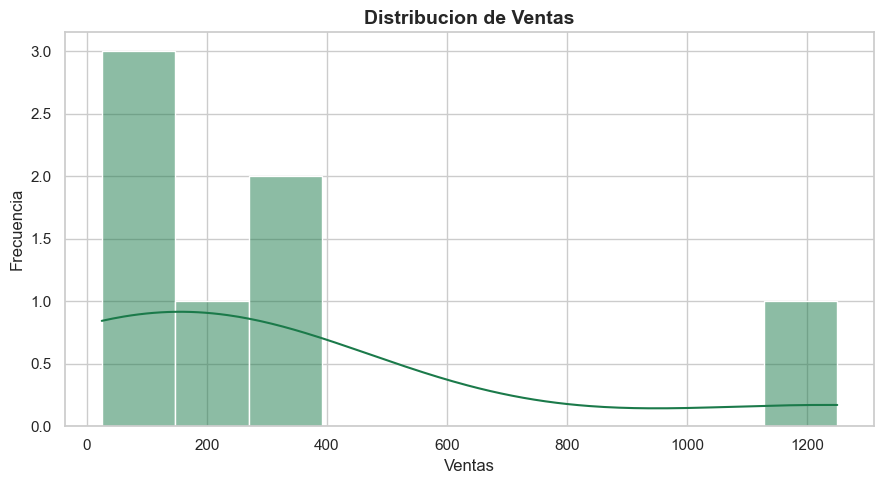

[LOG] Generando grafico de barras por producto...


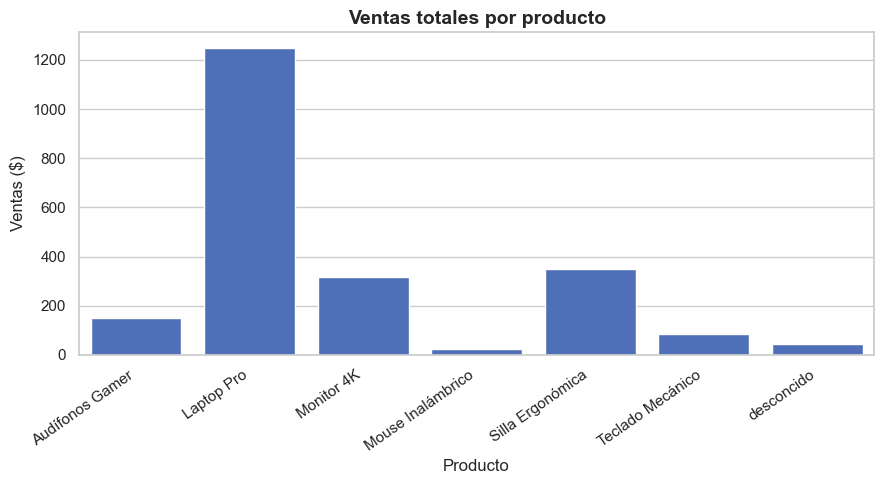

[LOG] Archivo limpio exportado correctamente en: ventas_limpias.csv


In [8]:
# ==========================================
# Fase 4: Ejecucion del Pipeline de Principio a Fin
# ==========================================

print("=== INICIANDO PIPELINE DE DATOS ===")
try:
    # 1. Fase de carga y validacion
    cargador = CargadorDatos("dataset.csv")
    df_crudo = cargador.ejecutar()

    # 2. Fase de limpieza de nulos y fechas
    limpiador = LimpiadorDatos(df_crudo)
    df_limpio = limpiador.ejecutar()

    print("\n--- Resumen estadistico (usando @property) ---")
    print(limpiador.resumen_estadistico)
    print("----------------------------------------------\n")

    # 3. Fase de analisis y reportes graficos
    analista = AnalistaDatos(df_limpio)
    analista.generar_reporte()

    # 4. Exportacion final del dataset curado
    analista.exportar_csv(df_limpio, "ventas_limpias.csv")

except Exception as e:
    print(f"[ERROR] Hubieron problemas durante la ejecucion: {str(e)}")
